In [646]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [647]:
from typing import Tuple

In [648]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 1 / 1000
RE = 1 / NU
T_MAX = 1
L_BOUNDS = [0, 0]
U_BOUNDS = [1, 1]
L=1

In [649]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [650]:
def g_N(x):
    return 4 * x[:, 0] * (1 - x[:, 0]) * x[:, 1]**2

def f(x):
    return 16 * x[:, 0] * (x[:, 0] - 1) * x[:, 1] * (x[:, 1] - 1)

def model_dec_uv(x: torch.Tensor, model_out: torch.Tensor):
    f_out = f(x)
    u_tilde = g_N(x) + f_out * model_out[:, 0]
    v_tilde = f_out * model_out[:, 0]
    
    return torch.cat([u_tilde.unsqueeze(1), v_tilde.unsqueeze(1)], dim=1)

In [651]:
model_uv_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    layer=[32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce_boundary=True,
    decorator=model_dec_uv
)

model_p_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    layer=[32, 32, 32],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_uv = mm.MLPModel(model_uv_ctx).to(device)
model_p = mm.MLPModel(model_p_ctx).to(device)

optim_uv = torch.optim.Adam(model_uv.parameters(), lr=5e-4)
optim_p = torch.optim.Adam(model_p.parameters(), lr=1e-4)

def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight, gain=torch.nn.init.calculate_gain('tanh'))
        torch.nn.init.zeros_(m.bias)

model_uv.apply(init_weights)
model_p.load_state_dict(model_uv.state_dict())

<All keys matched successfully>

In [652]:

def model_decorator(model_in : torch.Tensor, model_out: torch.Tensor):
    return bnd_model(model_in) + torch.mul(smoothing_fn(model_in), model_out)

In [ ]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(u: torch.Tensor, v:torch.Tensor, p: torch.Tensor, input: torch.Tensor):    
    u_grad = grad(u, input, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, input, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, input, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, input, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, input, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    res_ct = u_x + v_y
    
    return res_a, res_b, res_ct
    
def pde_loss_uv(model: torch.nn.Module, domain: cb.CubeDomain):
    model.train()
    model_p.eval()
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    uv_out = model_uv(pde_pts)
    u, v = uv_out[:, 0], uv_out[:, 1]
    
    param_flags = [p.requires_grad for p in model_p.parameters()]
    for par in model_p.parameters():
        par.requires_grad = False
    
    p = model_p(pde_pts)[:, 0]

    for par, flag in zip(model_p.parameters(), param_flags):
        par.requires_grad = flag

    pde_res_a, pde_res_b, pde_res_ct  = pde_res(u, v, p, pde_pts)

    return [torch.mean(pde_res_a**2 + pde_res_b**2), L * torch.mean(pde_res_ct**2)]

def pde_loss_p(model: torch.nn.Module, domain: cb.CubeDomain):
    model.train()
    model_uv.eval()
    
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    uv_out = model_uv(pde_pts)
    
    param_flags = [p.requires_grad for p in model_uv.parameters()]
    for par in model_uv.parameters():
        par.requires_grad = False
    
    u, v = uv_out[:, 0], uv_out[:, 1]
    
    for par, flag in zip(model_uv.parameters(), param_flags):
        par.requires_grad = flag
    
    p = model_p(pde_pts)[:, 0]

    pde_res_a, pde_res_b, _  = pde_res(u, v, p, pde_pts)
    
    return [torch.mean(pde_res_a**2 + pde_res_b**2)]

In [654]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=1_500,
    N_sides=[(0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [655]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100
)

# 
def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    out = model_uv(x)
    u = out[:, 0:1]
    v = out[:, 1:2]
    
    return torch.cat([u, v], dim=1)

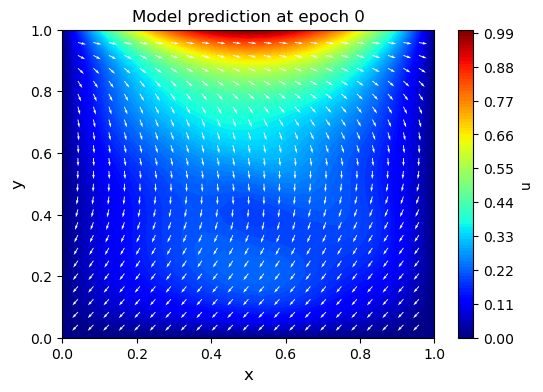

Starting cycle 1/60
Holding p-model const; training uv-model...
Loss at epoch 1 is: 0.13720403611660004. Total gradient norm: 0.14422149529435527 Current learing rate: 0.0005 


KeyboardInterrupt: 

In [ ]:
train_uv_ctx = train.TrainingContext(
    model=model_uv,
    optimizer=optim_uv,
    domain=domain,
    loss_fn=pde_loss_uv,
    resample=True,
    epochs=500,
    monitor_gradient=True,
    monitor_lr=True
)

train_p_ctx = train.TrainingContext(
    model=model_p,
    optimizer=optim_p,
    domain=domain,
    loss_fn=pde_loss_p,
    resample=True,
    epochs=500,
    monitor_gradient=True,
    monitor_lr=True
)

CYCLES = 60

for cycle in range(CYCLES):
    if cycle % 10 == 0:
        plot_ctx.titles = [f'Model prediction at epoch {cycle * 1000}'] 
        utils.plot_vector_field_2d([velocity], plot_ctx, N=25, n_heigth=25, n_width=25)
    
    print(f"Starting cycle {cycle+1}/{CYCLES}")
    print("Holding p-model const; training uv-model...")
    _, _ = train.simple_train(train_uv_ctx)
    
    print("Holding uv-model const; training p-model...")
    _, _ = train.simple_train(train_p_ctx)

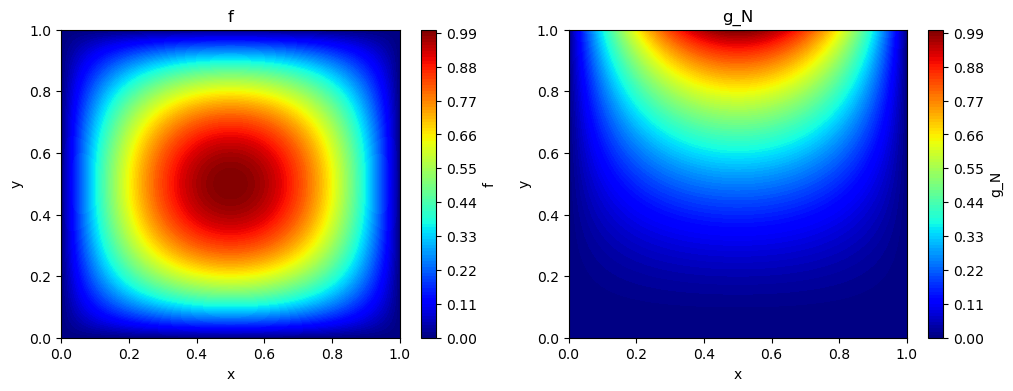

In [ ]:
plot_ctx.vmin=0
plot_ctx.vmax=1
plot_ctx.titles = ['f', 'g_N']
plot_ctx.function_names = ['f', 'g_N']
plot_ctx.figsize=(12, 4)


utils.plot_function_on_2d_cube([f, g_N], plot_ctx)

#utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)